# Setting Awal

In [1]:
# ======================================
# 📌 1. Mount Google Drive
# ======================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ======================================
# 📦 2️⃣ Install & Import Library
# ======================================
!pip install emoji seaborn transformers

import pandas as pd
import numpy as np
import pickle
import torch
from transformers import BertTokenizer, BertForTokenClassification, pipeline
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam      # ✅ Tambahkan untuk compile ulang
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import re
import emoji
import string
import nltk
from nltk.stem import WordNetLemmatizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 1.7 MB/s eta 0:00:00


In [3]:
# ======================================
# 📥 3️⃣ Download Resource NLP
# ======================================
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [4]:
# ======================================
# 🔧 4️⃣ Path file model & data
# ======================================
BERT_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/bert_ate_finetuned"
LSTM_MODEL_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/lstm_model.h5"
TOKENIZER_SENTENCE_PATH = "/content/drive/MyDrive/Tugas Akhir/Model/tokenizer_sentence.pkl"
TOKENIZER_ASPECT_PATH = "/content/drive/MyDrive/Tugas Akhir//Model/tokenizer_aspect.pkl"
DATA_FULL_PATH = "/content/drive/MyDrive/Tugas Akhir/3.Analisis/Dataset v1/tt29623480_segmented.csv" # The Wild Robot

MAX_LEN_SENTENCE = 50
MAX_LEN_ASPECT = 4
BATCH_SIZE = 16

In [5]:
# ======================================
# 📂 5️⃣ Load Dataset Ground Truth
# ======================================
df_full = pd.read_csv(DATA_FULL_PATH)
print("Jumlah dataset:", len(df_full))
df_full.head()

Jumlah dataset: 10096


,Movie_ID,Movie_Name,Date,Rating,Sentence
0,tt29623480,The Wild Robot,"Sep 27, 2024",9,I loved this movie.
1,tt29623480,The Wild Robot,"Sep 27, 2024",9,It has a wonderful message of tolerance and un...
2,tt29623480,The Wild Robot,"Sep 27, 2024",9,The voice acting is charming.
3,tt29623480,The Wild Robot,"Sep 27, 2024",9,"The animation is very good, stunning at times."
4,tt29623480,The Wild Robot,"Sep 27, 2024",9,"I liked the story, though I can see some peopl..."


# BERT

In [6]:
# ======================================
# 🔠 6️⃣ Load BERT Aspect Extractor
# ======================================
aspect_extractor = pipeline("token-classification",
                            model=BERT_MODEL_PATH,
                            tokenizer=BERT_MODEL_PATH,
                            device=0)   # ⚡ pakai GPU jika tersedia

Device set to use cpu


In [7]:
# ======================================
# 🏷️ 7️⃣ Ekstraksi Aspek + Simpan ID dan Nama Film
# ======================================
test_data = df_full.drop_duplicates(subset=['Sentence'])[['Movie_ID', 'Movie_Name', 'Sentence']]

def extract_aspects_batch(sentences, batch_size=32):
    all_aspects = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]
        batch_aspects = []
        for sentence in batch:
            results = aspect_extractor(sentence)
            aspects = []
            for r in results:
                if 'entity_group' in r:
                    if r['entity_group'] == 'ASP':
                        aspects.append(r['word'])
                elif 'entity' in r:
                    if r['entity'].endswith('ASP'):
                        aspects.append(r['word'])
            batch_aspects.append(aspects)
        all_aspects.extend(batch_aspects)
    return all_aspects

extracted_aspects = extract_aspects_batch(test_data['Sentence'].tolist(), BATCH_SIZE)

# Gabungkan ID, Nama Film, Kalimat, dan Aspek
pairs = []
for (movie_id, movie_name, sentence), aspects in zip(test_data.values, extracted_aspects):
    for asp in aspects:
        pairs.append((movie_id, movie_name, sentence, asp))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))
print("Contoh:", pairs[:5])

✅ Total pasangan kalimat-aspek hasil ekstraksi: 5990
Contoh: [('tt29623480', 'The Wild Robot', 'It has a wonderful message of tolerance and unity.', 'message'), ('tt29623480', 'The Wild Robot', 'The voice acting is charming.', 'voice'), ('tt29623480', 'The Wild Robot', 'The voice acting is charming.', 'acting'), ('tt29623480', 'The Wild Robot', 'The animation is very good, stunning at times.', 'animation'), ('tt29623480', 'The Wild Robot', "I liked the story, though I can see some people feeling it's too schmaltzy or corny.", 'story')]


# LSTM

In [8]:
# ======================================
# 🔤 8️⃣ Preprocessing untuk LSTM
# ======================================
def preprocessing(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(f"[{string.punctuation}]", '', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    text = ' '.join(words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

pairs_cleaned = []
for movie_id, movie_name, sentence, asp in pairs:
    pairs_cleaned.append((movie_id,
                          movie_name,
                          preprocessing(sentence),
                          preprocessing(asp)))

print("✅ Total pasangan kalimat-aspek hasil ekstraksi:", len(pairs))

✅ Total pasangan kalimat-aspek hasil ekstraksi: 5990


In [9]:
# ======================================
# 🔢 9️⃣ Tokenisasi LSTM
# ======================================
with open(TOKENIZER_SENTENCE_PATH, "rb") as f:
    tokenizer_sentence = pickle.load(f)

with open(TOKENIZER_ASPECT_PATH, "rb") as f:
    tokenizer_aspect = pickle.load(f)

sentences_cleaned = [p[2] for p in pairs_cleaned]
aspects_cleaned = [p[3] for p in pairs_cleaned]

seq_sentence = tokenizer_sentence.texts_to_sequences(sentences_cleaned)
seq_aspect = tokenizer_aspect.texts_to_sequences(aspects_cleaned)

pad_sentence = pad_sequences(seq_sentence, maxlen=MAX_LEN_SENTENCE, padding='post', truncating='post')
pad_aspect = pad_sequences(seq_aspect, maxlen=MAX_LEN_ASPECT, padding='post', truncating='post')

In [10]:
# ======================================
# 🔮 🔟 Klasifikasi Sentimen dengan LSTM (GPU jika ada)
# ======================================
lstm_model = load_model(LSTM_MODEL_PATH)

# compile ulang biar jelas
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

print("🚀 Mulai prediksi dengan LSTM...")
pred_probs = lstm_model.predict([pad_sentence, pad_aspect], batch_size=32)
pred_labels = (pred_probs >= 0.5).astype(int).flatten()

label_map = {0: "negative", 1: "positive"}
pred_sentiments = [label_map[l] for l in pred_labels]

pipeline_results = pd.DataFrame(pairs, columns=["Movie_ID", "Movie_Name", "sentence", "aspect"])
pipeline_results["Predicted_Sentiment"] = pred_sentiments

pipeline_results.head()

🚀 Mulai prediksi dengan LSTM...
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


,Movie_ID,Movie_Name,sentence,aspect,Predicted_Sentiment
0,tt29623480,The Wild Robot,It has a wonderful message of tolerance and un...,message,positive
1,tt29623480,The Wild Robot,The voice acting is charming.,voice,positive
2,tt29623480,The Wild Robot,The voice acting is charming.,acting,positive
3,tt29623480,The Wild Robot,"The animation is very good, stunning at times.",animation,positive
4,tt29623480,The Wild Robot,"I liked the story, though I can see some peopl...",story,positive


# Analisis Umum Aspek Dominan dan Kecenderungan Sentimen

5 Aspek Saja

In [11]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_aspect(aspect):
    tokens = nltk.word_tokenize(aspect.lower())
    pos_tags = nltk.pos_tag(tokens, lang='eng')
    lemmatized_tokens = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tags]
    return ' '.join(lemmatized_tokens)

pipeline_results["aspect_lemma"] = pipeline_results["aspect"].apply(lemmatize_aspect)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [12]:
from IPython.display import display

# Hitung jumlah sentimen per aspek per film
sentiment_summary = (
    pipeline_results.groupby(["Movie_Name", "aspect_lemma", "Predicted_Sentiment"])
    .size()
    .unstack(fill_value=0)  # hasilnya ada kolom positive & negative
    .reset_index()
)

# Hapus nama axis kolom yang terbawa dari unstack
sentiment_summary.columns.name = None

# Tambah total frekuensi aspek
sentiment_summary["count"] = sentiment_summary["positive"] + sentiment_summary["negative"]

# Ambil 5 aspek teratas per film berdasarkan frekuensi
top_aspects_per_movie = sentiment_summary.groupby("Movie_Name").apply(
    lambda x: x.sort_values("count", ascending=False).head(5)
).reset_index(drop=True)

# Tampilkan tabel lebih bersih
for movie, group in top_aspects_per_movie.groupby("Movie_Name"):
    print(f"\nTop 5 Aspects for {movie}:\n")
    display(group[["aspect_lemma", "count", "positive", "negative"]])


Top 5 Aspects for The Wild Robot:



/tmp/ipython-input-998019932.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_aspects_per_movie = sentiment_summary.groupby("Movie_Name").apply(


,aspect_lemma,count,positive,negative
0,story,961,632,329
1,character,643,462,181
2,animation,553,508,45
3,theme,261,231,30
4,voice,229,205,24


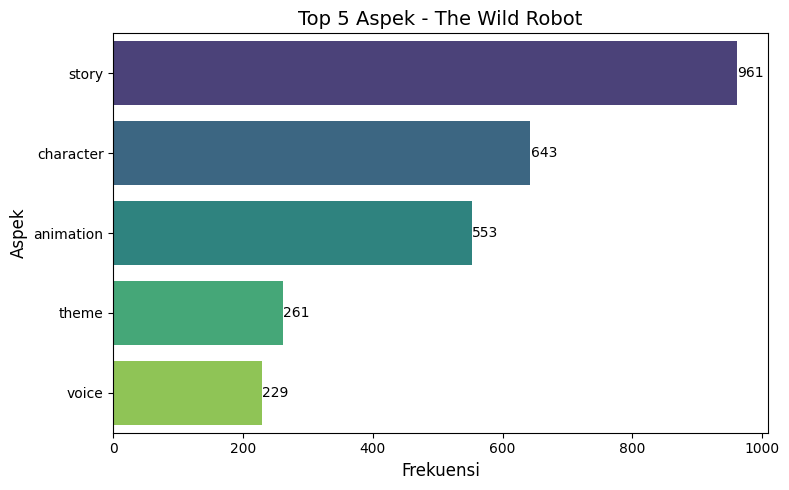

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop setiap film dan buat bar chart 5 aspek teratas
for movie in top_aspects_per_movie["Movie_Name"].unique():
    movie_data = top_aspects_per_movie[top_aspects_per_movie["Movie_Name"] == movie]

    plt.figure(figsize=(8,5))
    colors = sns.color_palette("viridis", len(movie_data))
    sns.barplot(
        x="count",
        y="aspect_lemma",
        data=movie_data,
        hue="aspect_lemma",
        palette=colors,
        legend=False
    )

    plt.title(f"Top 5 Aspek - {movie}", fontsize=14)
    plt.xlabel("Frekuensi", fontsize=12)
    plt.ylabel("Aspek", fontsize=12)

    for index, value in enumerate(movie_data["count"]):
        plt.text(value + 0.1, index, str(value), va='center')

    plt.tight_layout()
    plt.show()

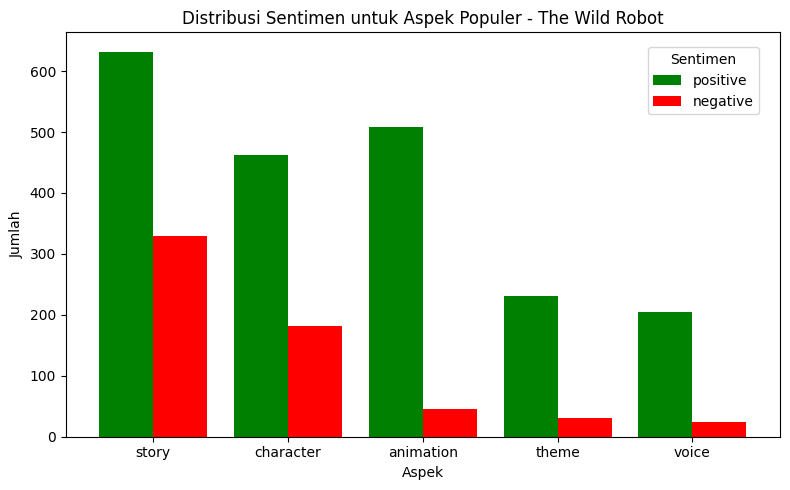

In [14]:
import matplotlib.pyplot as plt

# Ambil daftar film unik
movies = pipeline_results["Movie_Name"].unique()

for movie in movies:
    # Filter data untuk film tertentu
    movie_df = pipeline_results[pipeline_results["Movie_Name"] == movie]

    # Ambil aspek populer (5 teratas per film)
    top_aspects_movie = (
        movie_df.groupby("aspect_lemma")
        .size()
        .sort_values(ascending=False)
        .head(5)
        .index.tolist()
    )

    # Filter hanya aspek populer
    popular_df = movie_df[movie_df["aspect_lemma"].isin(top_aspects_movie)]

    # Hitung distribusi sentimen untuk setiap aspek
    sentiment_dist = (
        popular_df.groupby(["aspect_lemma", "Predicted_Sentiment"])
        .size()
        .reset_index(name="count")
    )

    # Pivot untuk visualisasi grouped bar
    pivot_df = sentiment_dist.pivot(
        index="aspect_lemma",
        columns="Predicted_Sentiment",
        values="count"
    ).fillna(0)

    # Pastikan semua kolom ada
    for col in ["positive", "negative"]:
        if col not in pivot_df.columns:
            pivot_df[col] = 0
    pivot_df = pivot_df[["positive", "negative"]]

    # Urutkan berdasarkan jumlah total (positif+negatif)
    pivot_df = pivot_df.reindex(
        pivot_df.sum(axis=1).sort_values(ascending=False).index
    )

    # Plot
    pivot_df.plot(
        kind="bar",
        stacked=False,
        figsize=(8, 5),
        color=["green", "red"],
        width=0.8
    )

    plt.title(f"Distribusi Sentimen untuk Aspek Populer - {movie}")
    plt.xlabel("Aspek")
    plt.ylabel("Jumlah")
    plt.xticks(rotation=0)  # label horizontal
    plt.legend(title="Sentimen", loc="upper right", bbox_to_anchor=(0.98, 0.98))
    plt.tight_layout()
    plt.show()

# Contoh Kalimat Per Aspek

In [15]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

In [16]:
def show_aspect_examples(df, aspects, n):
    """
    Menampilkan contoh kalimat positif & negatif untuk beberapa aspek.

    Parameters:
        df (DataFrame) : pipeline_results
        aspects (list) : daftar aspek (string) yang ingin ditampilkan
        n (int)        : jumlah contoh positif/negatif per aspek
    """
    for aspect in aspects:
        asp_df = df[df['aspect_lemma'].str.lower() == aspect.lower()]
        print("="*60)
        print(f"Contoh review dengan aspek '{aspect}':")

        # Positive
        pos = asp_df[asp_df['Predicted_Sentiment'] == "positive"].head(n)
        print("\n--- Positive ---")
        if not pos.empty:
            print(pos[['sentence', 'aspect_lemma', 'Predicted_Sentiment']])
        else:
            print("Tidak ada contoh positif.")

        # Negative
        neg = asp_df[asp_df['Predicted_Sentiment'] == "negative"].head(n)
        print("\n--- Negative ---")
        if not neg.empty:
            print(neg[['sentence', 'aspect_lemma', 'Predicted_Sentiment']])
        else:
            print("Tidak ada contoh negatif.")
        print("\n")

In [17]:
# --- Penggunaan ---
top_aspects = ["story", "character", "animation", "theme", "voice"]
show_aspect_examples(pipeline_results, top_aspects, n=10)

Contoh review dengan aspek 'story':

--- Positive ---
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         sentence  \
4                                                                                                                                                                                                                                                                                                            

In [18]:
# ### 🔹 2. Wordcloud Aspek Dominan

# from wordcloud import WordCloud

# wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(aspect_counts))

# plt.figure(figsize=(12, 6))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis('off')
# # plt.title("WordCloud Aspek yang Paling Sering Muncul")
# plt.show()